<a href="https://colab.research.google.com/github/hsmu-jeongeun/health-infomatics/blob/main/10_Medical_Imaging_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 10주차 실습: 의료 영상과 딥러닝 (CNN)

## 학습 목표
- 의료 영상 데이터가 컴퓨터 배열(Array)로 표현되는 원리를 이해할 수 있다
- CNN(합성곱 신경망)의 기본 개념을 이해할 수 있다
- Keras로 간단한 이미지 분류 모델을 구성하고 실행할 수 있다

---

## 오늘의 핵심 개념: X-ray도 숫자 배열이다

> 흑백 사진을 아주 가까이서 보면 수많은 작은 점으로 이루어져 있음. 컴퓨터는 이 픽셀 하나를 0~255 사이의 밝기값으로 저장.
> X-ray도 하나의 이미지 = 하나의 숫자 배열

### 전자의무기록 인증제도와 의료 영상
- **10주차 연계:** EMR 인증제도의 핵심 기능 중 하나가 PACS(의료영상저장전송시스템)와의 연동
- **DICOM 형식:** 의료 영상의 국제 표준 포맷 (CT, MRI, X-ray)
- **AI의 의료 영상 분석:**
  - 흉부 X-ray → 폐렴·결절 검출
  - 유방조영술 → 종양 자동 탐지
  - 안저 사진 → 당뇨망막병증 스크리닝

### CNN(Convolutional Neural Network)이란?
- 이미지 인식에 특화된 딥러닝 모델
- **합성곱 필터:** 이미지에서 에지, 텍스처, 패턴을 자동으로 학습
- **의료 영상 AI의 핵심 기술**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

print('기본 라이브러리 로드 완료!')

기본 라이브러리 로드 완료!


## Part 1. 이미지 = 숫자 배열 체험

이미지 배열 shape: (8, 8)  (세로 x 가로)
픽셀값 범위: 0 ~ 255

이미지 배열 (숫자):
[[  0   0   0   0   0   0   0   0]
 [  0 255 255   0   0 255 255   0]
 [  0 255 255   0   0 255 255   0]
 [  0   0   0   0   0   0   0   0]
 [255   0   0   0   0   0   0 255]
 [  0 255   0   0   0   0 255   0]
 [  0   0 255 255 255 255   0   0]
 [  0   0   0   0   0   0   0   0]]


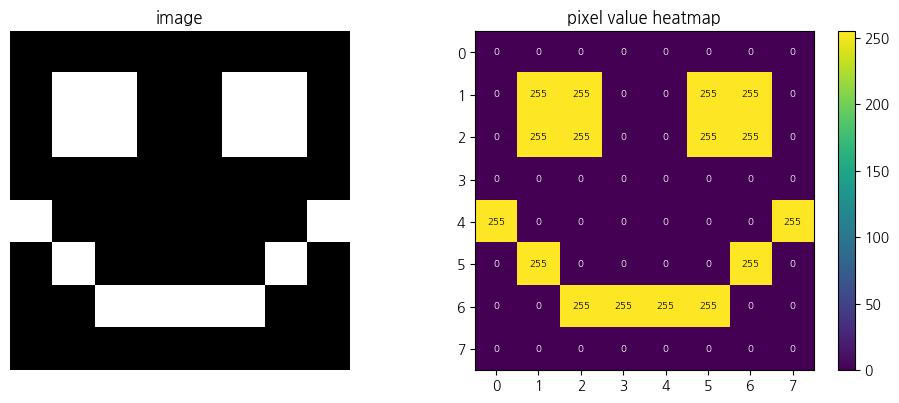

In [ ]:
# 간단한 8x8 흑백 이미지 만들기
# 0 = 검은색, 255 = 흰색
simple_image = np.array([
    [  0,   0,   0,   0,   0,   0,   0,   0],
    [  0, 255, 255,   0,   0, 255, 255,   0],
    [  0, 255, 255,   0,   0, 255, 255,   0],
    [  0,   0,   0,   0,   0,   0,   0,   0],
    [255,   0,   0,   0,   0,   0,   0, 255],
    [  0, 255,   0,   0,   0,   0, 255,   0],
    [  0,   0, 255, 255, 255, 255,   0,   0],
    [  0,   0,   0,   0,   0,   0,   0,   0]
], dtype=np.uint8)

print(f'이미지 배열 shape: {simple_image.shape}  (세로 x 가로)')
print(f'픽셀값 범위: {simple_image.min()} ~ {simple_image.max()}')
print('\n이미지 배열 (숫자):')
print(simple_image)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(simple_image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('image', fontsize=12)
axes[0].axis('off')

im = axes[1].imshow(simple_image, cmap='viridis')
axes[1].set_title('pixel value heatmap', fontsize=12)
for i in range(8):
    for j in range(8):
        axes[1].text(j, i, simple_image[i,j], ha='center', va='center', fontsize=7,
                     color='white' if simple_image[i,j] < 128 else 'black')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

## Part 2. 실제 크기 의료 영상 시뮬레이션

흉부 X-ray를 모사한 가상의 이미지를 생성합니다.

가상 X-ray 이미지 shape: (256, 256)
픽셀값 평균: 0.128
픽셀값 범위: 0.000 ~ 0.851


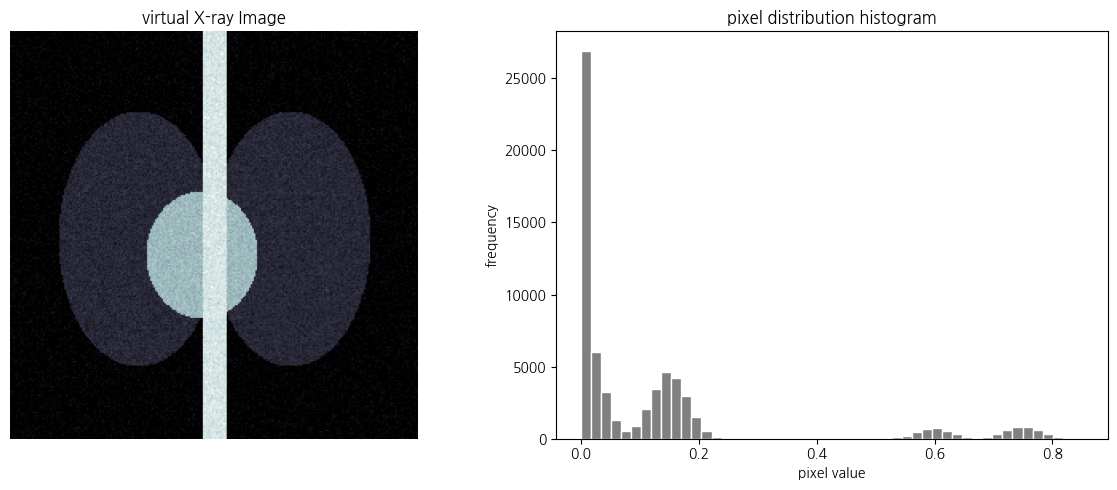

In [ ]:
np.random.seed(42)

# 가상의 흉부 X-ray 이미지 (256 x 256 픽셀)
H, W = 256, 256
xray = np.zeros((H, W), dtype=np.float32)

# 배경 — 폐 영역 (어두운 회색)
y_idx, x_idx = np.mgrid[0:H, 0:W]

# 왼쪽 폐
left_lung  = ((x_idx - 80)**2/50**2 + (y_idx - 130)**2/80**2) < 1.0
# 오른쪽 폐
right_lung = ((x_idx - 176)**2/50**2 + (y_idx - 130)**2/80**2) < 1.0
# 심장
heart      = ((x_idx - 120)**2/35**2 + (y_idx - 140)**2/40**2) < 1.0
# 척추/늑골 (밝은 영역)
spine      = np.abs(x_idx - 128) < 8

xray[left_lung | right_lung] = 0.15  # 폐: 어두움
xray[heart] = 0.6                    # 심장: 밝음
xray[spine] = 0.75                   # 척추: 밝음
xray = xray + np.random.normal(0, 0.03, (H, W))  # 노이즈
xray = np.clip(xray, 0, 1)

print(f'가상 X-ray 이미지 shape: {xray.shape}')
print(f'픽셀값 평균: {xray.mean():.3f}')
print(f'픽셀값 범위: {xray.min():.3f} ~ {xray.max():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(xray, cmap='bone')
axes[0].set_title('virtual X-ray Image', fontsize=12)
axes[0].axis('off')

axes[1].hist(xray.flatten(), bins=50, color='gray', edgecolor='white')
axes[1].set_title('pixel distribution histogram', fontsize=12)
axes[1].set_xlabel('pixel value')
axes[1].set_ylabel('frequency')
plt.tight_layout()
plt.show()

## Part 3. CNN으로 폐렴 분류 체험

**Keras + TensorFlow**를 이용한 CNN 분류 모델  
※ 가짜 흉부 X-ray 분류(정상 vs 폐렴)를 학습 데이터로 구성

In [ ]:
# TensorFlow/Keras 불러오기
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
print(f'TensorFlow 버전: {tf.__version__}')

TensorFlow 버전: 2.21.0


In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

# 가상의 흉부 X-ray 데이터셋 생성 (64x64 이미지)
IMG_SIZE = 64
N        = 400  # 총 이미지 수 (정상 200 + 폐렴 200)

# 정상 이미지: 노이즈 적음, 균일한 밝기
X_normal  = np.random.normal(0.15, 0.04, (200, IMG_SIZE, IMG_SIZE, 1)).clip(0, 1)
# 폐렴 이미지: 불균일한 밝기 패턴 (침윤 영역 시뮬레이션)
X_pneumo  = np.random.normal(0.15, 0.04, (200, IMG_SIZE, IMG_SIZE, 1)).clip(0, 1)
# 폐렴 이미지에 밝은 패치(침윤) 추가
for i in range(200):
    cy, cx = np.random.randint(10, 54), np.random.randint(10, 54)
    r      = np.random.randint(5, 12)
    yy, xx = np.mgrid[0:IMG_SIZE, 0:IMG_SIZE]
    mask   = (yy-cy)**2 + (xx-cx)**2 < r**2
    X_pneumo[i, mask, 0] += np.random.uniform(0.3, 0.5)
X_pneumo = X_pneumo.clip(0, 1)

X = np.vstack([X_normal, X_pneumo]).astype(np.float32)
y = np.array([0]*200 + [1]*200)

# 섞기
idx = np.random.permutation(N)
X, y = X[idx], y[idx]

# 분할 (80/20)
split = int(N * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'학습 데이터: {X_train.shape}, 레이블: {y_train.shape}')
print(f'테스트 데이터: {X_test.shape}')

학습 데이터: (320, 64, 64, 1), 레이블: (320,)
테스트 데이터: (80, 64, 64, 1)


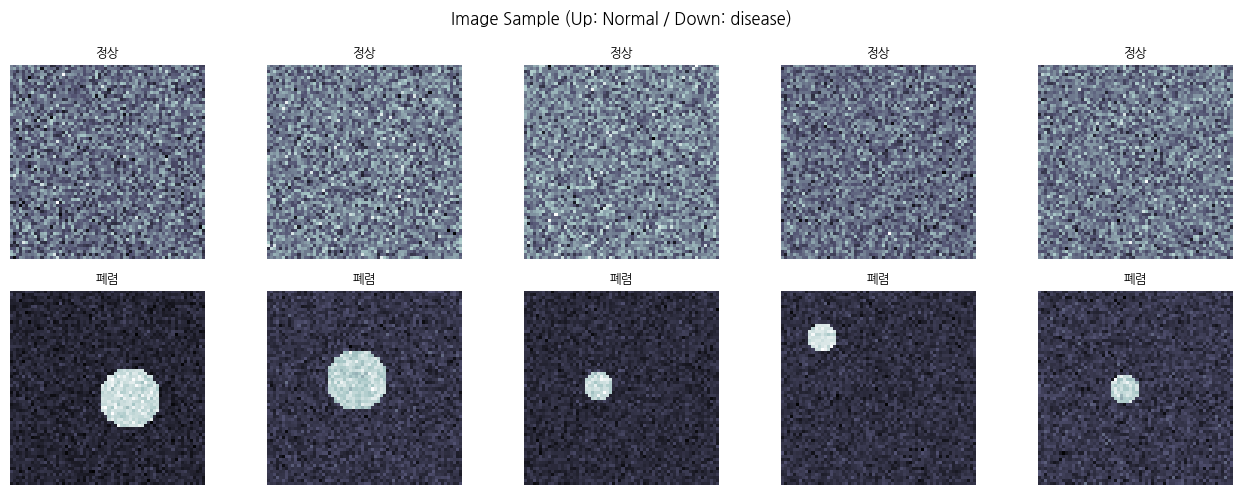

In [ ]:
# 이미지 샘플 시각화
fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for i, ax in enumerate(axes[0]):
    ax.imshow(X_normal[i, :, :, 0], cmap='bone')
    ax.set_title('정상', fontsize=9)
    ax.axis('off')
for i, ax in enumerate(axes[1]):
    ax.imshow(X_pneumo[i, :, :, 0], cmap='bone')
    ax.set_title('폐렴', fontsize=9)
    ax.axis('off')
plt.suptitle('Image Sample (Up: Normal / Down: disease)', fontsize=12)
plt.tight_layout()
plt.show()

## Part 4. CNN 모델 구성 및 학습

In [ ]:
# CNN 모델 구성
model = keras.Sequential([
    # 합성곱 블록 1
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D((2,2)),
    # 합성곱 블록 2
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    # 완전연결층
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # 이진 분류
], name='XRay_CNN')

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "XRay_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 406,337 (1.55 MB)

 Trainable params: 406,337 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =====================
# 수정해 보세요!
# =====================
EPOCHS = 10  # 학습 횟수 (5~20으로 변경 가능)
# =====================

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\n최종 테스트 정확도: {test_acc:.4f} ({test_acc*100:.1f}%)')

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5594 - loss: 0.6868 - val_accuracy: 0.4625 - val_loss: 0.6771
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5094 - loss: 0.6518 - val_accuracy: 0.4625 - val_loss: 0.6414
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5031 - loss: 0.5856 - val_accuracy: 0.4625 - val_loss: 0.5778
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7719 - loss: 0.4839 - val_accuracy: 0.9500 - val_loss: 0.4659
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9750 - loss: 0.3698 - val_accuracy: 1.0000 - val_loss: 0.3440
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9844 - loss: 0.2483 - val_accuracy: 1.0000 - val_loss: 0.1869
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9750 - loss: 0.1454 - val_accuracy: 1.0000 - val_loss: 0.1010
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9844 - loss: 0.0861 - val_accuracy: 1.0000 - v

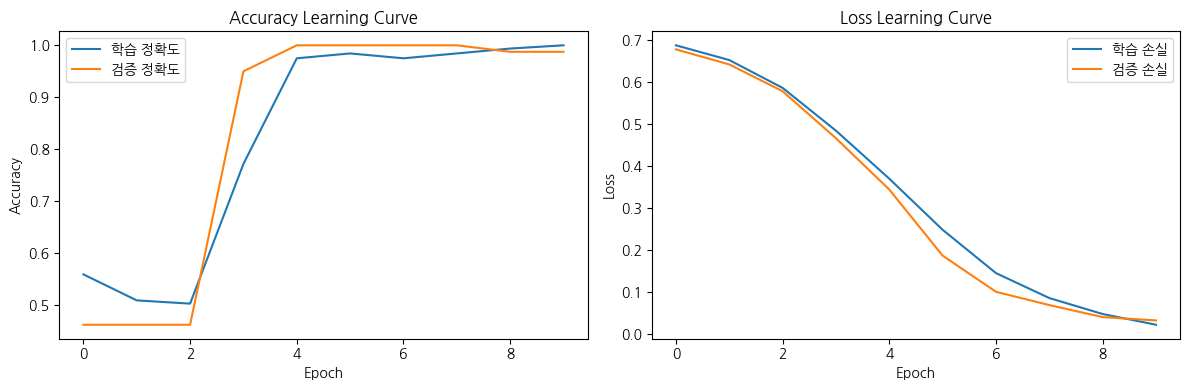

In [ ]:
# 학습 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='학습 정확도')
axes[0].plot(history.history['val_accuracy'], label='검증 정확도')
axes[0].set_title('Accuracy Learning Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='학습 손실')
axes[1].plot(history.history['val_loss'], label='검증 손실')
axes[1].set_title('Loss Learning Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

---

## Canvas 퀴즈 안내

아래 코드 셀을 실행하여 나온 **숫자**를 Canvas 퀴즈의 정답으로 제출하세요.

**문제:** 학습에 사용한 CNN 모델(`model.summary()`)에서 **전체 학습 가능한 파라미터(Trainable params)의 수**는?

In [ ]:
# [실습] 아래 코드를 실행하여 나온 결과를 Canvas 퀴즈의 정답으로 제출
canvas_answer = model.count_params()
print(f'Answer: {canvas_answer}')